In [17]:
import polars as pl

In [20]:
df = pl.read_parquet("../data/results.parquet")
df_filtered = df.filter(
    pl.col("col_value").list.eval(pl.element().str.contains("VMA")).list.any()
)
df_filtered

bioproject,col_name,col_value,statistic,pvalue,mean_positive,std_positive,count_positive,mean_negative,std_negative,count_negative
str,list[str],list[str],f64,f64,f64,f64,i32,f64,f64,i32
"""PRJNA664803""","[""genotype_attrib""]","[""MATa [HAP1+::NatMX-ACT1pr-Z3EV-ENO2term] [barcode-URA3-Z3EVpr-VMA3] [can1delta::STE2pr-SpHIS5] his3delta1 lyp1delta0 ura3delta0""]",6462.0,2.2437e-11,24.960148,12.139127,19,6.351905,4.686752,356


In [ ]:
# get all rows where bioproject is PRJNA664803
filtered_bioproject = df.filter(pl.col("bioproject") == "PRJNA664803")
filtered_bioproject

bioproject,col_name,col_value,statistic,pvalue,mean_positive,std_positive,count_positive,mean_negative,std_negative,count_negative
str,list[str],list[str],f64,f64,f64,f64,i32,f64,f64,i32
"""PRJNA664803""","[""genotype_attrib""]","[""MATa [HAP1+::NatMX-ACT1pr-Z3EV-ENO2term] [barcode-URA3-Z3EVpr-BAT1] [can1delta::STE2pr-SpHIS5] his3delta1 lyp1delta0 ura3delta0""]",2884.0,0.158256,4.889907,2.317182,20,7.430206,6.821325,355
"""PRJNA664803""","[""genotype_attrib""]","[""MATa [HAP1+::NatMX-ACT1pr-Z3EV-ENO2term] [barcode-URA3-Z3EVpr-SHM2] [can1delta::STE2pr-SpHIS5] his3delta1 lyp1delta0 ura3delta0""]",3824.0,0.562007,6.581661,3.243263,20,7.334896,6.82414,355
"""PRJNA664803""","[""genotype_attrib""]","[""MATa [HAP1+::NatMX-ACT1pr-Z3EV-ENO2term] [barcode-URA3-Z3EVpr-HO] [can1delta::STE2pr-SpHIS5] his3delta1 lyp1delta0 ura3delta0""]",4763.0,0.283942,7.305957,4.060453,24,7.293955,6.827836,351
"""PRJNA664803""","[""genotype_attrib""]","[""MATa [HAP1+::NatMX-ACT1pr-Z3EV-ENO2term] [barcode-URA3-Z3EVpr-SNF12] [can1delta::STE2pr-SpHIS5] his3delta1 lyp1delta0 ura3delta0""]",3389.0,0.497408,6.103898,4.538548,21,7.365365,6.785351,354
"""PRJNA664803""","[""genotype_attrib""]","[""MATa [HAP1+::NatMX-ACT1pr-Z3EV-ENO2term] [barcode-URA3-Z3EVpr-TRP4] [can1delta::STE2pr-SpHIS5] his3delta1 lyp1delta0 ura3delta0""]",2748.0,0.089262,5.001815,3.328833,20,7.423901,6.801124,355
…,…,…,…,…,…,…,…,…,…,…
"""PRJNA664803""","[""genotype_attrib""]","[""MATa [HAP1+::NatMX-ACT1pr-Z3EV-ENO2term] [barcode-URA3-Z3EVpr-SRS2] [can1delta::STE2pr-SpHIS5] his3delta1 lyp1delta0 ura3delta0""]",2785.0,0.105048,5.157056,3.89537,20,7.415155,6.787979,355
"""PRJNA664803""","[""genotype_attrib""]","[""MATa [HAP1+::NatMX-ACT1pr-Z3EV-ENO2term] [barcode-URA3-Z3EVpr-TIP41] [can1delta::STE2pr-SpHIS5] his3delta1 lyp1delta0 ura3delta0""]",3264.0,0.544977,5.796821,3.497756,20,7.379112,6.809791,355
"""PRJNA664803""","[""genotype_attrib""]","[""MATa [HAP1+::NatMX-ACT1pr-Z3EV-ENO2term] [barcode-URA3-Z3EVpr-VMA3] [can1delta::STE2pr-SpHIS5] his3delta1 lyp1delta0 ura3delta0""]",6462.0,2.2437e-11,24.960148,12.139127,19,6.351905,4.686752,356


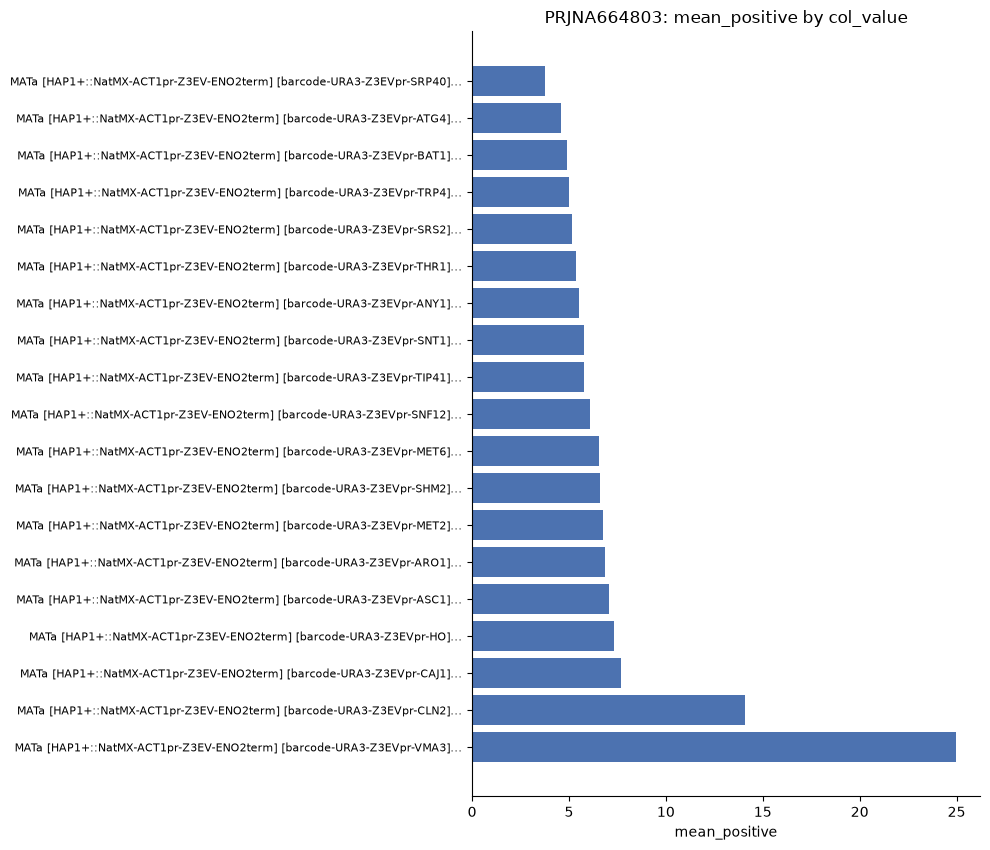

In [23]:
import textwrap
import matplotlib.pyplot as plt

# plot mean_positive for each row, sorted lowest to highest
plot_df = filtered_bioproject.sort("mean_positive").with_columns(
    pl.col("col_value").list.join("; ").alias("label")
)
labels = [textwrap.shorten(s, width=80, placeholder="...") for s in plot_df["label"]]

fig, ax = plt.subplots(figsize=(10, 0.4 * len(plot_df) + 1))
ax.barh(range(len(plot_df)), plot_df["mean_positive"], color="#4C72B0")
ax.set_yticks(range(len(plot_df)), labels, fontsize=8)
ax.invert_yaxis()  # lowest at top
ax.set_xlabel("mean_positive")
ax.set_title("PRJNA664803: mean_positive by col_value")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()